# Data Mining Lab 2: Classical Credit Approval Classification

This notebook completes the credit approval analysis without neural networks. It includes data preparation, exploratory data analysis, leakage-free preprocessing, Logistic Regression, a Decision Tree classifier, 10-fold cross-validation, Grid Search, and model comparison.

The target is `A16`, where `+` means approved and `-` means rejected.

## 1. Imports and Reproducibility

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / 'dataset').exists() else Path.cwd().parent
DATA_PATH = NOTEBOOK_DIR / 'dataset' / 'crx.data'
OUTPUT_PATH = NOTEBOOK_DIR / 'prepared_credit_approval_classical.csv'
print(f'Dataset path: {DATA_PATH}')
print(f'Output path: {OUTPUT_PATH}')

Dataset path: /Users/optimsprime/Downloads/Documents/Msc in Big Data Analytics/Semester 4/Data Mining/Data Mining/Lab 2 - Classification/dataset/crx.data
Output path: /Users/optimsprime/Downloads/Documents/Msc in Big Data Analytics/Semester 4/Data Mining/Data Mining/Lab 2 - Classification/prepared_credit_approval_classical.csv


## 2. Dataset and Data Preparation

The raw UCI file has no header. The 15 predictors and final class column are named from the dataset documentation. The source marker `?` is interpreted as a missing value.

In [2]:
column_names = [f'A{i}' for i in range(1, 17)]
credit_df = pd.read_csv(DATA_PATH, header=None, names=column_names, na_values='?')
credit_df = credit_df.replace(r'^\s+|\s+$', '', regex=True)
credit_df['A16'] = credit_df['A16'].astype('string')
print(f'Shape: {credit_df.shape}')
display(credit_df.head())
display(credit_df.dtypes.to_frame('dtype'))
display(credit_df.describe(include='all').T)
credit_df.to_csv(OUTPUT_PATH, index=False)
print(f'Prepared DataFrame saved to: {OUTPUT_PATH}')

Shape: (690, 16)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


,dtype
A1,str
A2,float64
A3,float64
A4,str
A5,str
A6,str
A7,str
A8,float64
A9,str
A10,str


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
A1,678,2,b,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A2,678.0,NaN,NaN,NaN,31.568171,11.957862,13.75,22.6025,28.46,38.23,80.25
A3,690.0,NaN,NaN,NaN,4.758725,4.978163,0.0,1.0,2.75,7.2075,28.0
A4,684,3,u,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A5,684,3,g,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A6,681,14,c,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A7,681,9,v,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A8,690.0,NaN,NaN,NaN,2.223406,3.346513,0.0,0.165,1.0,2.625,28.5
A9,690,2,t,361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A10,690,2,f,395,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Prepared DataFrame saved to: /Users/optimsprime/Downloads/Documents/Msc in Big Data Analytics/Semester 4/Data Mining/Data Mining/Lab 2 - Classification/prepared_credit_approval_classical.csv


## 3. Exploratory Data Analysis

### 3.1 Overview and missing values

In [3]:
target_column = 'A16'
feature_columns = [column for column in credit_df.columns if column != target_column]
numeric_columns = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
categorical_columns = [column for column in feature_columns if column not in numeric_columns]
missing_summary = pd.DataFrame({'missing_count': credit_df.isna().sum(), 'missing_percent': (credit_df.isna().mean() * 100).round(2)})
print(f'Observations: {len(credit_df)}')
print(f'Features: {len(feature_columns)}')
print(f'Numerical attributes: {numeric_columns}')
print(f'Categorical attributes: {categorical_columns}')
display(missing_summary[missing_summary['missing_count'] > 0])
display(credit_df[target_column].value_counts(dropna=False).rename('count').to_frame())

Observations: 690
Features: 15
Numerical attributes: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Categorical attributes: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


,missing_count,missing_percent
A1,12,1.74
A2,12,1.74
A4,6,0.87
A5,6,0.87
A6,9,1.30
A7,9,1.30
A14,13,1.88


,count
A16,
-,383
+,307


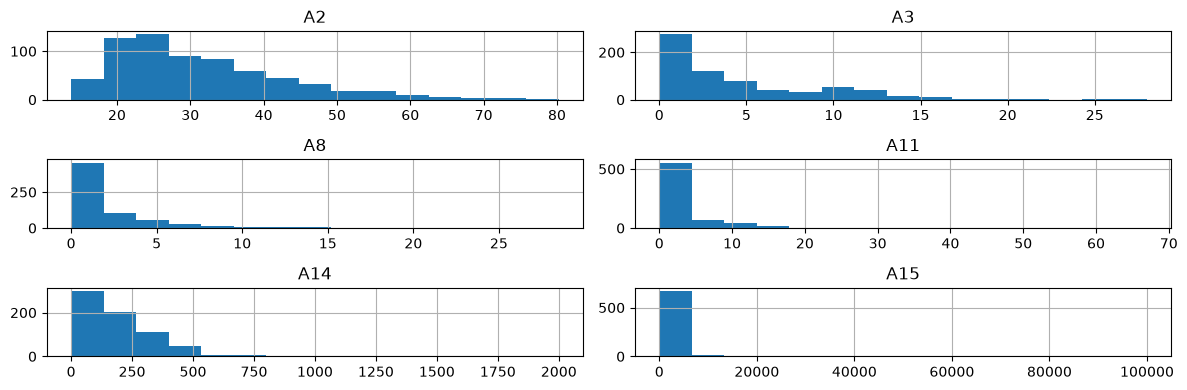

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
credit_df[target_column].value_counts().plot(kind='bar', ax=axes[0], color=['#2a9d8f', '#e76f51'])
axes[0].set_title('Credit approval distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Applications')
credit_df[numeric_columns].hist(ax=axes[1], bins=15, figsize=(6, 4))
axes[1].set_title('Numerical feature distributions')
plt.tight_layout()
plt.show()

The target distribution is inspected before modeling. Accuracy is useful for overall correctness, while F1-score balances precision and recall when the class counts are not identical. The numeric histograms show differing ranges and some skew, supporting scaling for the linear model.

### 3.2 Outlier investigation

Potential outliers are identified with the IQR rule and retained. Removing credit applications arbitrarily could discard meaningful profiles, so the models receive the complete dataset after principled imputation and transformation.

,lower_bound,upper_bound,potential_outliers
feature,,,
A2,-0.83875,61.67125,16
A3,-8.31125,16.51875,17
A8,-3.52500,6.31500,63
A11,-4.50000,7.50000,79
A14,-226.50000,577.50000,13
A15,-593.25000,988.75000,113


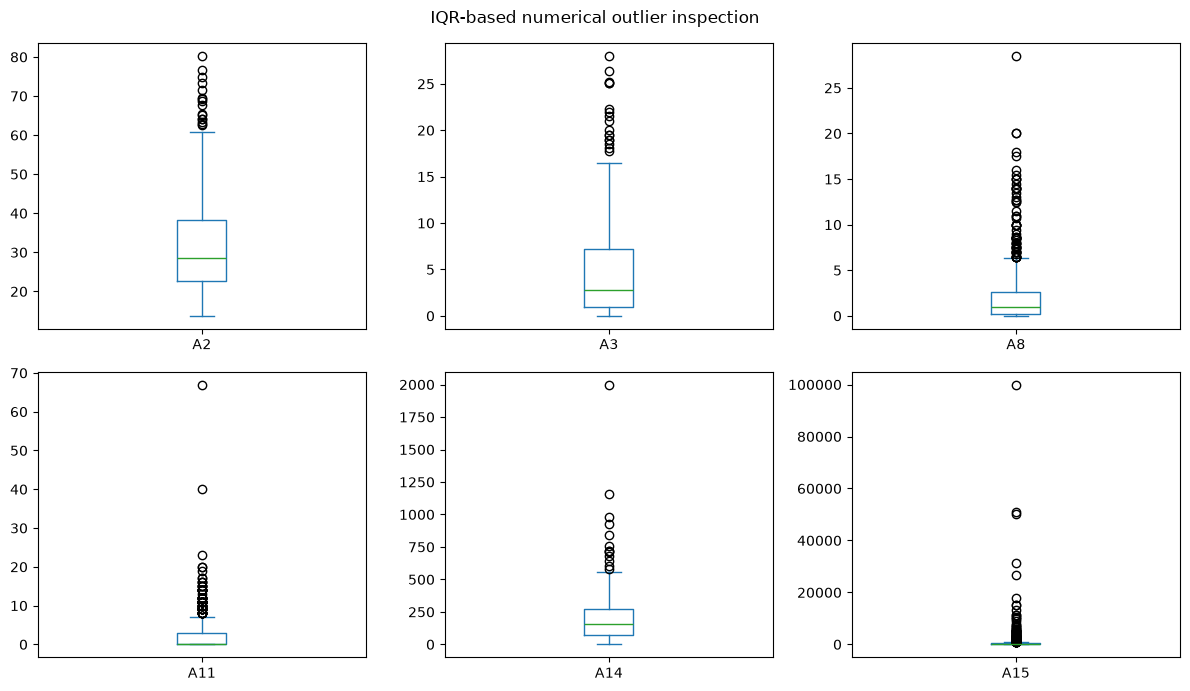

In [5]:
outlier_rows = []
for column in numeric_columns:
    values = credit_df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((values < lower) | (values > upper)).sum()
    outlier_rows.append({'feature': column, 'lower_bound': lower, 'upper_bound': upper, 'potential_outliers': int(count)})
outlier_summary = pd.DataFrame(outlier_rows).set_index('feature')
display(outlier_summary)
credit_df[numeric_columns].plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 7), sharey=False)
plt.suptitle('IQR-based numerical outlier inspection')
plt.tight_layout()
plt.show()

StandardScaler is fitted only within training folds. This reduces the influence of differing numeric units for Logistic Regression; the Decision Tree itself is not dependent on feature scale, but it uses the same encoded, imputed feature representation for a fair comparison.

## 4. Preprocessing and Train/Test Split

Median imputation is used for numeric values, most-frequent imputation for categorical values, and one-hot encoding for nominal categories. Keeping these operations in a pipeline prevents data leakage during cross-validation.

In [6]:
X = credit_df[feature_columns].copy()
y = credit_df[target_column].map({'+': 1, '-': 0}).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('numeric', numeric_pipeline, numeric_columns), ('categorical', categorical_pipeline, categorical_columns)])
print(f'Training rows: {len(X_train)}; testing rows: {len(X_test)}')
print(f'Encoded target distribution: {y.value_counts().to_dict()}')

Training rows: 552; testing rows: 138
Encoded target distribution: {0: 383, 1: 307}


No target-derived features are created because the attributes are anonymous. All documented predictors are retained; regularisation and tree constraints are tuned using training data only.

## 5. Classification Model: Logistic Regression

Logistic Regression is an interpretable binary classification baseline. Accuracy and F1-score are reported because together they show overall correctness and the balance between precision and recall.

Accuracy    0.8696
F1-score    0.8525
dtype: float64
              precision    recall  f1-score   support

    Rejected       0.88      0.88      0.88        77
    Approved       0.85      0.85      0.85        61

    accuracy                           0.87       138
   macro avg       0.87      0.87      0.87       138
weighted avg       0.87      0.87      0.87       138



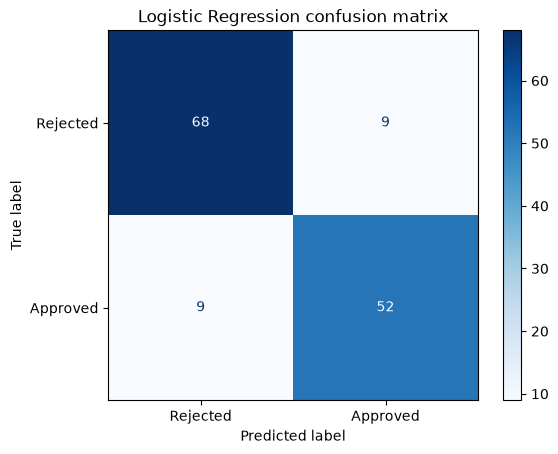

In [7]:
logistic_model = Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)
baseline_results = {'Accuracy': accuracy_score(y_test, logistic_predictions), 'F1-score': f1_score(y_test, logistic_predictions)}
print(pd.Series(baseline_results).round(4))
print(classification_report(y_test, logistic_predictions, target_names=['Rejected', 'Approved']))
ConfusionMatrixDisplay.from_predictions(y_test, logistic_predictions, display_labels=['Rejected', 'Approved'], cmap='Blues')
plt.title('Logistic Regression confusion matrix')
plt.show()

## 6. Classical Decision Tree Model

A Decision Tree provides a non-linear, rule-based alternative to Logistic Regression. Its performance is estimated with stratified 10-fold cross-validation on the training partition. The test partition remains untouched until the final comparison.

In [8]:
tree_model = Pipeline([('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))])
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'f1': 'f1'}
tree_cv = cross_validate(tree_model, X_train, y_train, cv=cv10, scoring=scoring, n_jobs=-1)
tree_cv_results = pd.DataFrame({'Accuracy': tree_cv['test_accuracy'], 'F1-score': tree_cv['test_f1']})
display(tree_cv_results.round(4))
display(tree_cv_results.agg(['mean', 'std']).round(4))

,Accuracy,F1-score
0,0.8214,0.8148
1,0.7500,0.7308
2,0.8727,0.8679
3,0.7636,0.7451
4,0.9273,0.9200
5,0.9091,0.8980
6,0.8000,0.7660
7,0.8000,0.7317
8,0.7273,0.7170
9,0.7818,0.7500


,Accuracy,F1-score
mean,0.8153,0.7941
std,0.0674,0.0756


The cross-validation mean estimates expected performance on unseen samples, while the standard deviation indicates sensitivity to the particular fold. Stratification preserves the approval/rejection proportions in each fold.

## 7. Hyperparameter Tuning with 10-Fold Grid Search

Grid Search tunes four Decision Tree hyperparameters: maximum depth, minimum samples required to split, minimum samples per leaf, and class weighting. F1-score is the selection objective because it accounts for both precision and recall.

In [9]:
grid_parameters = {
    'classifier__max_depth': [3, 5, 8, None],
    'classifier__min_samples_split': [2, 10],
    'classifier__min_samples_leaf': [1, 5],
    'classifier__class_weight': [None, 'balanced']
}
grid_search = GridSearchCV(estimator=tree_model, param_grid=grid_parameters, scoring='f1', cv=cv10, n_jobs=-1, refit=True, return_train_score=False)
grid_search.fit(X_train, y_train)
print(f'Grid combinations evaluated: {len(grid_search.cv_results_["params"])}')
print('Best parameters:')
display(pd.Series(grid_search.best_params_))
print(f'Best mean 10-fold F1-score: {grid_search.best_score_:.4f}')
print(f'Best estimator: {grid_search.best_estimator_}')

Grid combinations evaluated: 32
Best parameters:


classifier__class_weight         NaN
classifier__max_depth            3.0
classifier__min_samples_leaf     1.0
classifier__min_samples_split    2.0
dtype: float64

Best mean 10-fold F1-score: 0.8153
Best estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['A2', 'A3', 'A8', 'A11',
                                                   'A14', 'A15']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                     

The best estimator is refitted on the full training partition. Because preprocessing is part of the estimator, each Grid Search fold learns imputation and encoding from its training subset only.

## 8. Final Model Comparison

The baseline Logistic Regression and tuned Decision Tree are evaluated on the same untouched test set using identical metrics.

,Accuracy,F1-score
Logistic Regression,0.8696,0.8525
Tuned Decision Tree,0.8261,0.7736


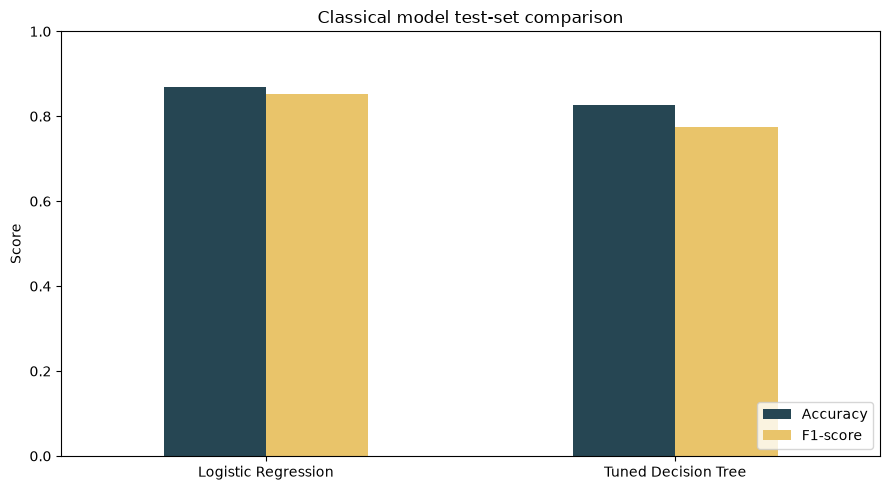

According to test-set F1-score, the stronger model is: Logistic Regression.


In [10]:
tuned_predictions = grid_search.best_estimator_.predict(X_test)
tuned_results = {'Accuracy': accuracy_score(y_test, tuned_predictions), 'F1-score': f1_score(y_test, tuned_predictions)}
comparison = pd.DataFrame([baseline_results, tuned_results], index=['Logistic Regression', 'Tuned Decision Tree'])
display(comparison.round(4))
comparison.plot(kind='bar', figsize=(9, 5), color=['#264653', '#e9c46a'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classical model test-set comparison')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
winner = comparison['F1-score'].idxmax()
print(f'According to test-set F1-score, the stronger model is: {winner}.')

## 9. Conclusion

This classical-only analysis prepared the credit approval data, investigated missing values and outliers, and evaluated two non-neural classification approaches. Logistic Regression supplies an interpretable baseline, while the Decision Tree supplies a non-linear alternative tuned through 10-fold Grid Search. The executed comparison table and chart provide the evidence for selecting the stronger model.